1. Downloading data for: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']...


[*********************100%***********************]  5 of 5 completed


✅ Data downloaded successfully! Shape: (1006, 5)
2. Running Monte Carlo Simulation (10,000 runs)...

---------------------------------------
   OPTIMAL PORTFOLIO ALLOCATION   
---------------------------------------
Annual Return:    50.85%
Annual Volatility:42.51%
Sharpe Ratio:     1.20
---------------------------------------
Weights:
AAPL: 30.37%
MSFT: 0.66%
GOOGL: 5.30%
AMZN: 17.80%
TSLA: 45.88%


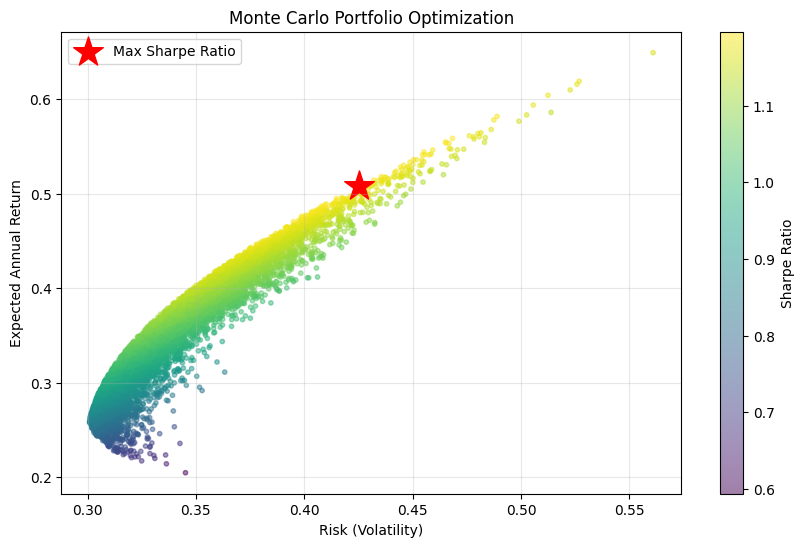

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
# We use a list of tech stocks. You can change these tickers.
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
start_date = '2020-01-01'
end_date = '2024-01-01'

print(f"1. Downloading data for: {tickers}...")

# --- DATA FETCHING (FIXED) ---
# auto_adjust=True accounts for dividends/splits automatically in the 'Close' column
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# Extract just the 'Close' prices
# If yfinance returns a MultiIndex (common in new versions), this handles it:
try:
    if 'Close' in raw_data.columns.levels[0]: 
        data = raw_data['Close']
    else:
        data = raw_data['Close']
except AttributeError:
    # Fallback for older versions or flat dataframes
    data = raw_data['Close']

if data.empty:
    print(" Error: No data downloaded.")
else:
    print(f"✅ Data downloaded successfully! Shape: {data.shape}")

# --- 2. CALCULATIONS ---
# Calculate Daily Returns (Percentage Change)
returns = data.pct_change().dropna()

# Calculate Mean Daily Returns and Covariance Matrix
mean_daily_returns = returns.mean()
cov_matrix = returns.cov()

# --- 3. MONTE CARLO SIMULATION ---
num_portfolios = 10000
results = np.zeros((3, num_portfolios)) # [Return, Volatility, Sharpe Ratio]
weights_record = [] 

print("2. Running Monte Carlo Simulation (10,000 runs)...")

for i in range(num_portfolios):
    # A. Generate Random Weights
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights) # Normalize to sum to 1
    weights_record.append(weights)
    
    # B. Calculate Portfolio Return & Volatility
    # Annualized Return (252 trading days)
    p_return = np.sum(mean_daily_returns * weights) * 252
    
    # Annualized Volatility (Standard Deviation)
    p_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    
    # C. Store Results
    results[0,i] = p_return
    results[1,i] = p_std_dev
    results[2,i] = p_return / p_std_dev # Sharpe Ratio (assuming 0% risk-free rate for simplicity)

# --- 4. OPTIMIZATION RESULTS ---
max_sharpe_idx = np.argmax(results[2])
optimal_weights = weights_record[max_sharpe_idx]

print("\n---------------------------------------")
print("   OPTIMAL PORTFOLIO ALLOCATION   ")
print("---------------------------------------")
print(f"Annual Return:    {results[0, max_sharpe_idx]:.2%}")
print(f"Annual Volatility:{results[1, max_sharpe_idx]:.2%}")
print(f"Sharpe Ratio:     {results[2, max_sharpe_idx]:.2f}")
print("---------------------------------------")
print("Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.2%}")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 6))
# Scatter plot of all portfolios
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
# Highlight the optimal portfolio
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], marker='*', color='red', s=500, label='Max Sharpe Ratio')

plt.title('Monte Carlo Portfolio Optimization')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()